In [2]:
from core import AnalysisConfig, Reference, ObsType
from utils.analyzer import Analyzer
from utils.plot_config import PlotLimits
from utils.workdirectory import WorkDirectory
from pathlib import Path

In [3]:
%config InlineBackend.figure_format = 'retina'

In [4]:
def is_curated_1d(ref: Reference, curated_list: list[str]) -> bool:
    """Check if 1D observable is in curated list."""
    return ObsType.is_var_1d(ref) and ref.observable_base in curated_list

def is_curated_2d(ref: Reference, curated_list: list[str]) -> bool:
    """Check if 2D observable has all variables in curated list."""
    if not ObsType.is_var_2d(ref):
        return False
    vars = ObsType.get_variable_names(ref)
    return all(var in curated_list for var in vars)

def filter_curated_refs(refs: list[Reference], curated_list: list[str]) -> tuple[list[Reference], list[Reference]]:
    """Filter references into 1D and 2D curated lists."""
    refs_1d = [ref for ref in refs if is_curated_1d(ref, curated_list)]
    refs_2d = [ref for ref in refs if is_curated_2d(ref, curated_list)]
    return refs_1d, refs_2d

curated_list = ['bjets_dR', 'jj_lnu_dPhi', 'bjets_pt_bb', 'bjets_dPhi',
       'bb_lnu_dPhi', 'bjet_bijet_dR', 'bb_lnu_dR', 'bjets_mbb',
       'trijet_bijet_dEta', 'met_pt', 'blnu_mT', 'bjets_dEta', 'all_sT',
       'blnu_pt']

Figure saved to SL_4j_resolved___bjets_mbb_llr.pdf


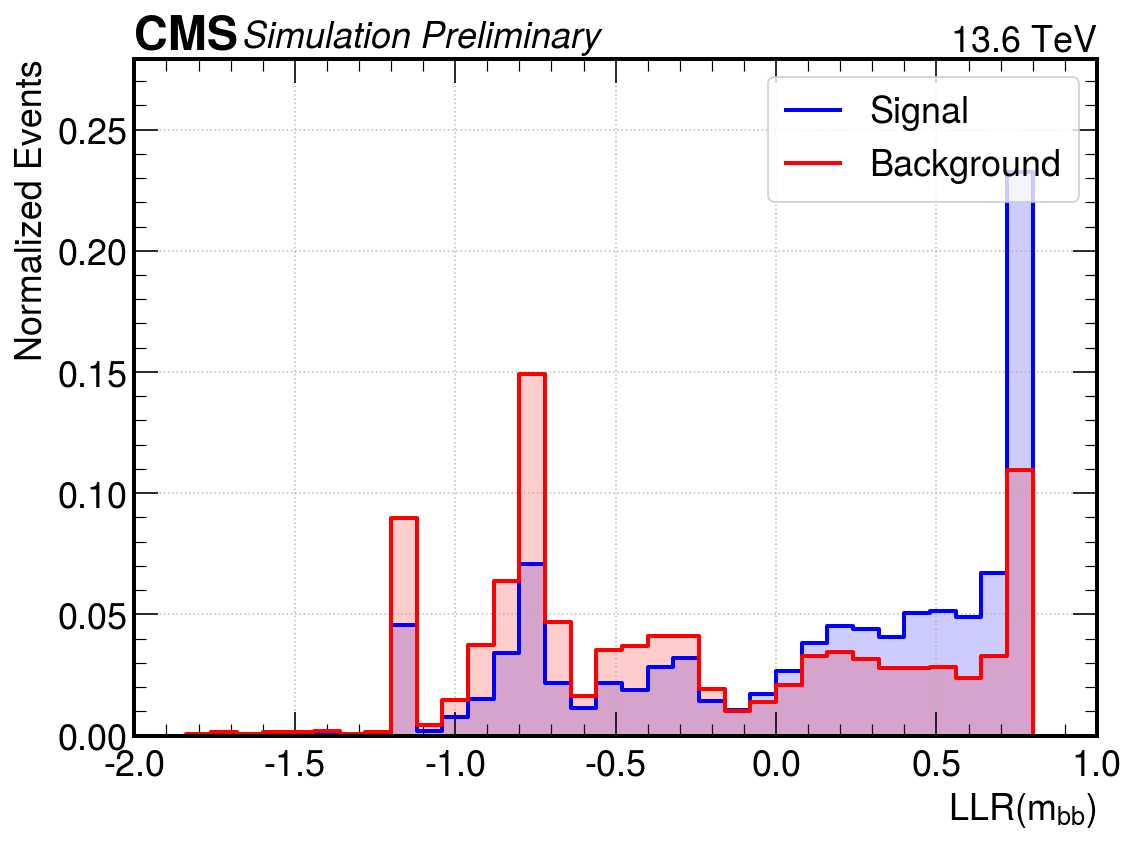

In [5]:
config = AnalysisConfig('bamboo_hh/config/disc_study_new.yml')
wd = WorkDirectory('/eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/LLR_crtd_odd')
refs = wd.get_references(channels=['SL_4j_resolved'])
llrs_list = [f'{var_name}_llr' for var_name in curated_list]
refs_llrs_from_1D = list(filter(lambda ref: ref.observable_base in llrs_list, refs))

analyzer = Analyzer(wd, config, output_dir=Path('.'))
analyzer.plot_sig_bkg(refs_llrs_from_1D[7], PlotLimits(xmin=-2.0, xmax=1.0))

In [6]:
workspace = WorkDirectory('/eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/JetTop_crtd_even')
refs = workspace.get_references(channels=['SL_4j_resolved'])
refs1D, refs2D = filter_curated_refs(refs, curated_list)

Figure saved to SL_4j_resolved___bjets_mbb.pdf


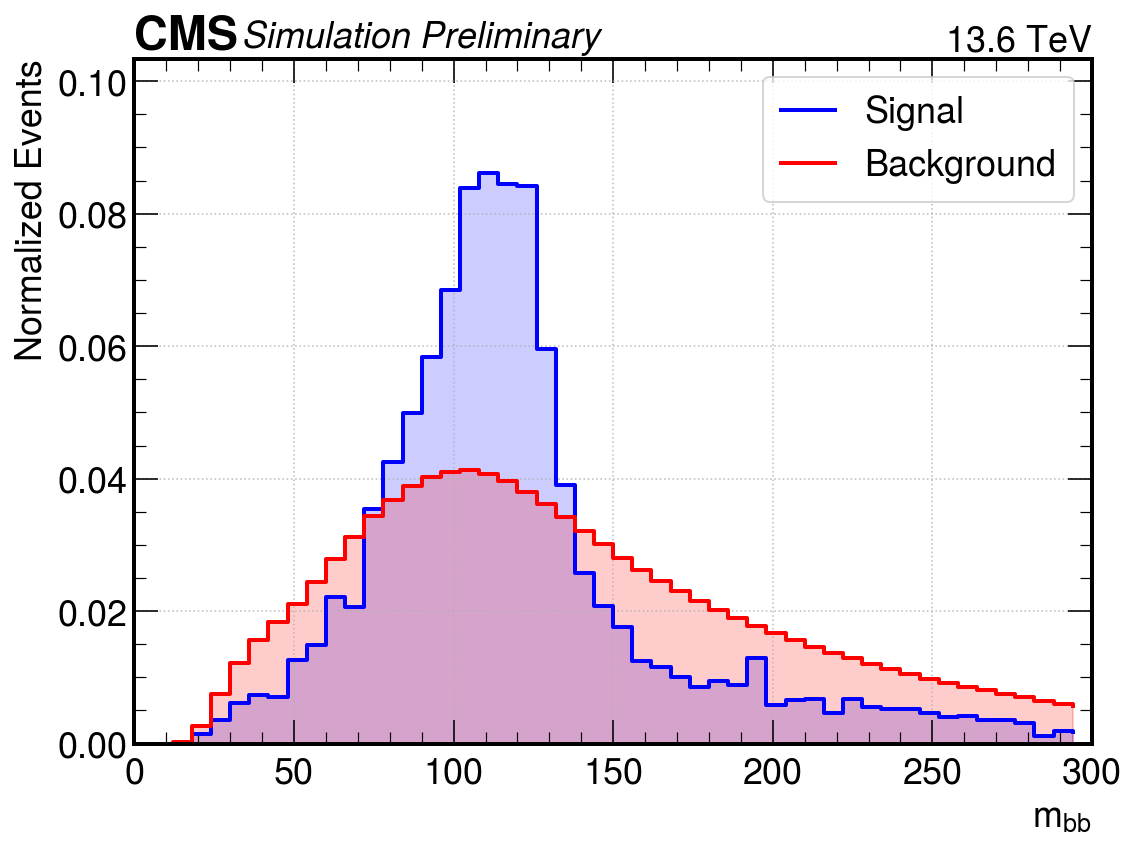

/afs/cern.ch/user/a/anunezde/bamboodev/hh/utils/analyzer.py:112: RuntimeWarning: divide by zero encountered in log
  values = np.log(values) if take_log else values


Figure saved to SL_4j_resolved___bjets_mbb_ratio.pdf


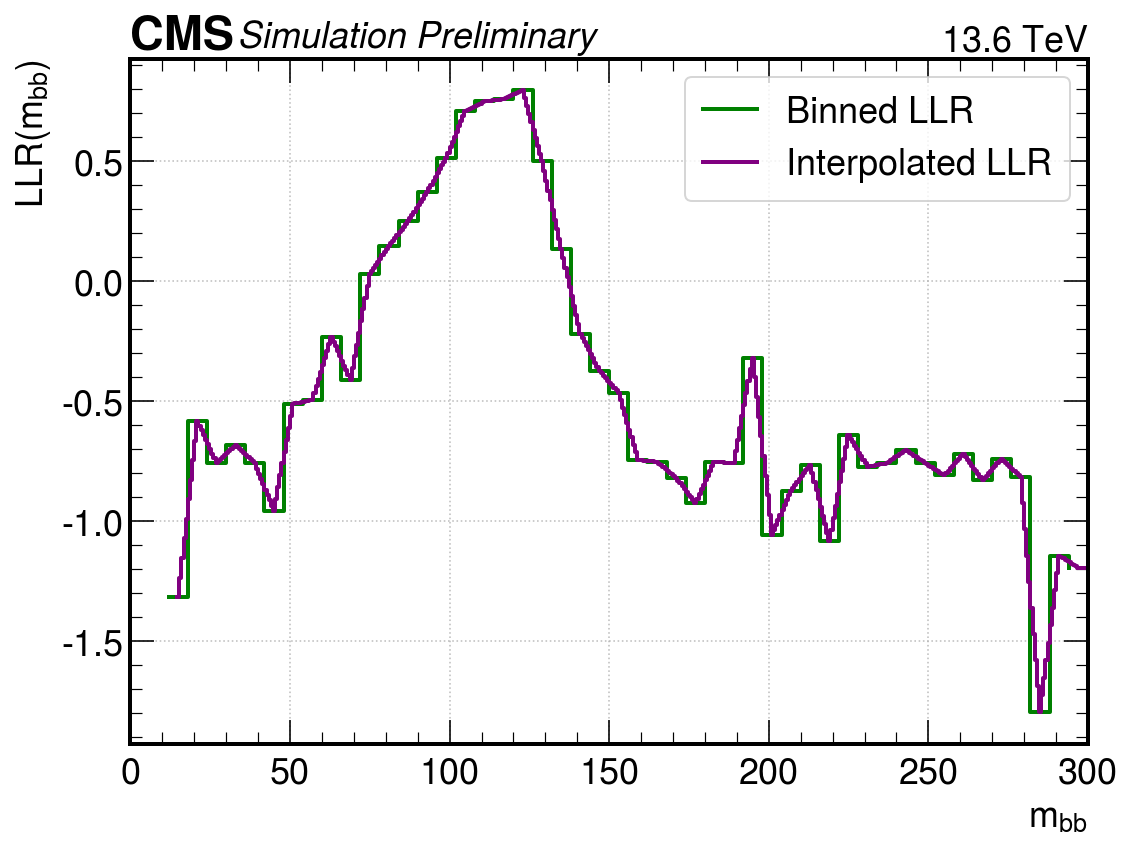

Figure saved to SL_4j_resolved___all_sT_vs_bjets_dR__signal.pdf


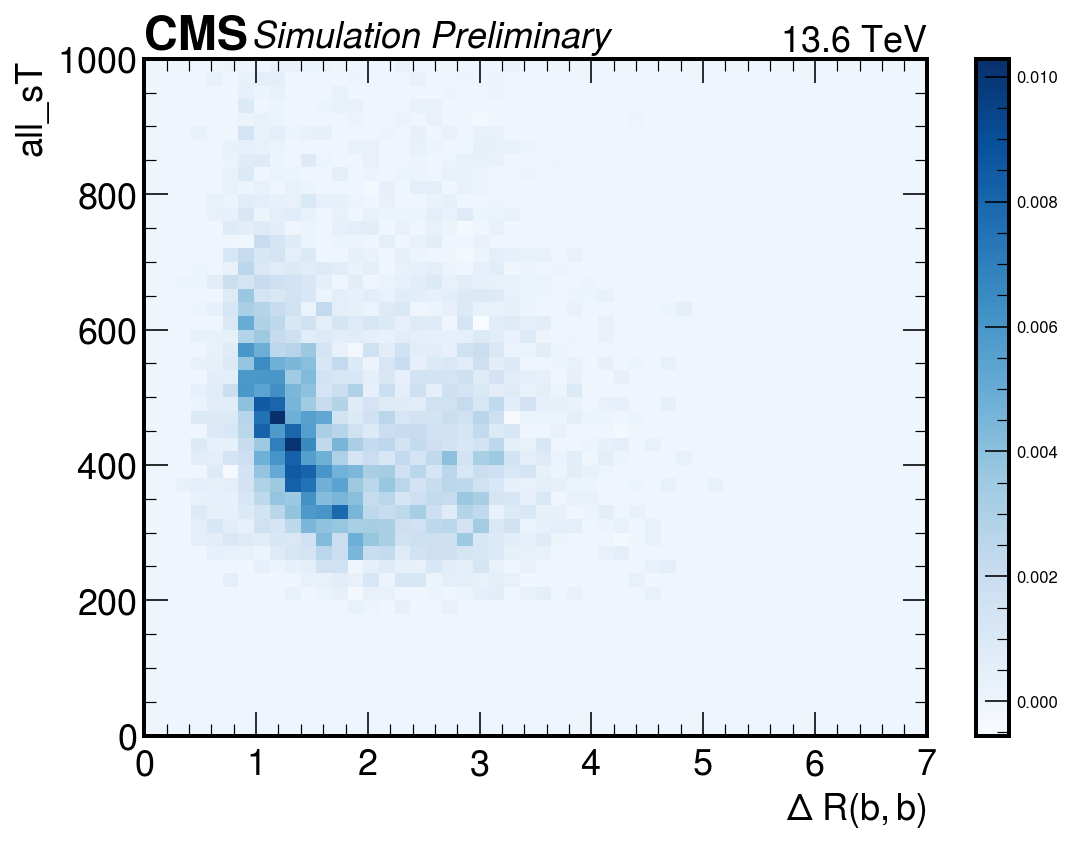

Figure saved to SL_4j_resolved___all_sT_vs_bjets_dR__bkg.pdf


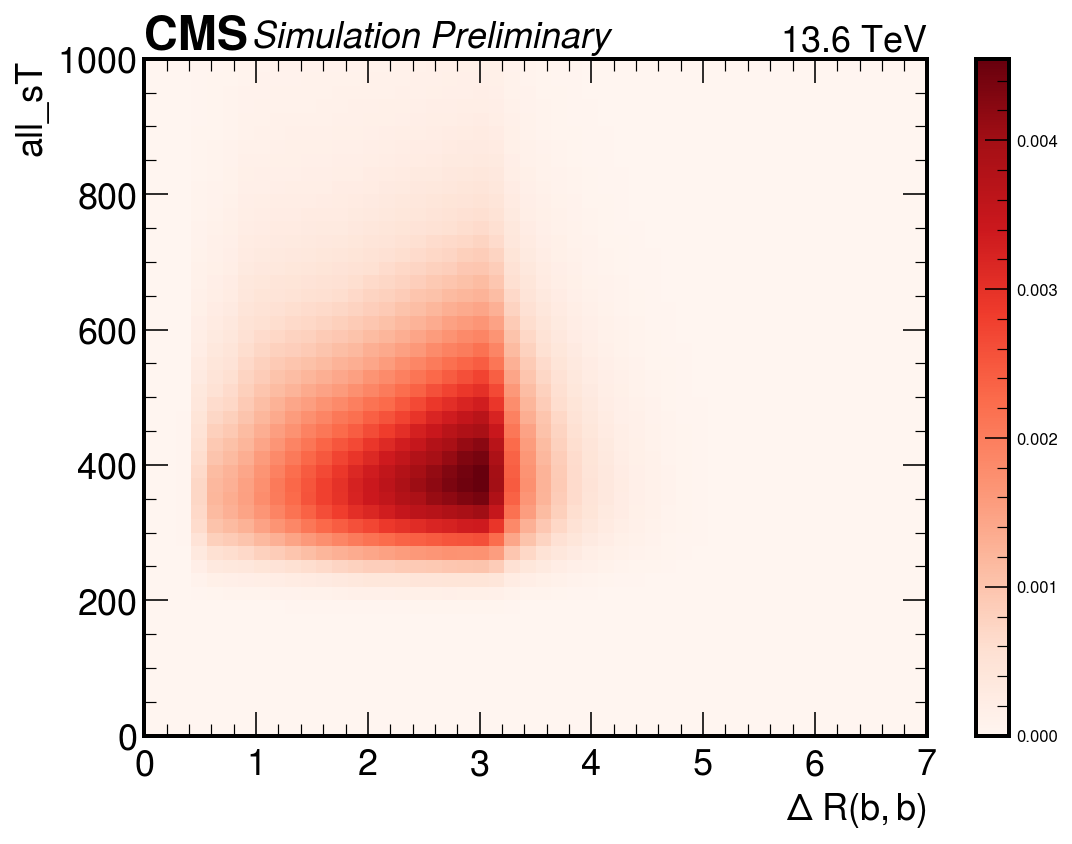

/afs/cern.ch/user/a/anunezde/bamboodev/hh/utils/analyzer.py:112: RuntimeWarning: divide by zero encountered in log
  values = np.log(values) if take_log else values
/afs/cern.ch/user/a/anunezde/bamboodev/hh/utils/analyzer.py:112: RuntimeWarning: invalid value encountered in log
  values = np.log(values) if take_log else values


Figure saved to SL_4j_resolved___all_sT_vs_bjets_dR_ratio.pdf


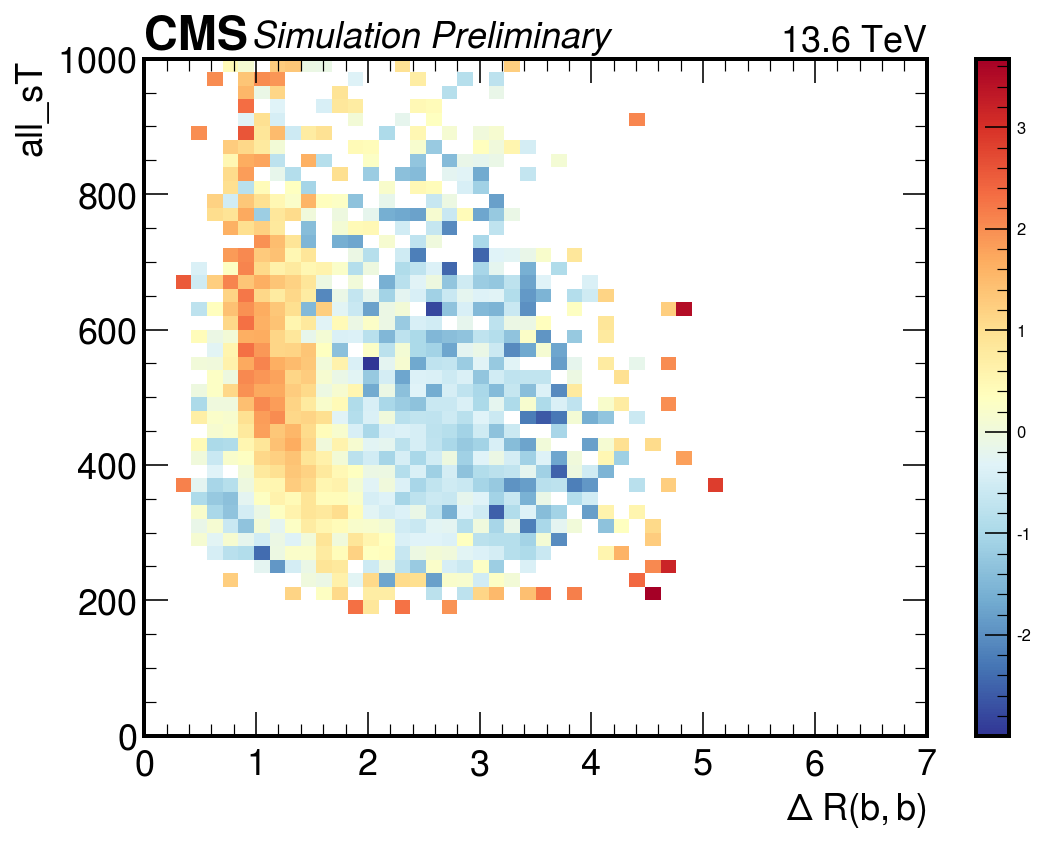

/afs/cern.ch/user/a/anunezde/bamboodev/hh/utils/analyzer.py:112: RuntimeWarning: divide by zero encountered in log
  values = np.log(values) if take_log else values
/afs/cern.ch/user/a/anunezde/bamboodev/hh/utils/analyzer.py:112: RuntimeWarning: invalid value encountered in log
  values = np.log(values) if take_log else values


Figure saved to SL_4j_resolved___bjet_bijet_dR_vs_bjets_mbb_ratio.pdf


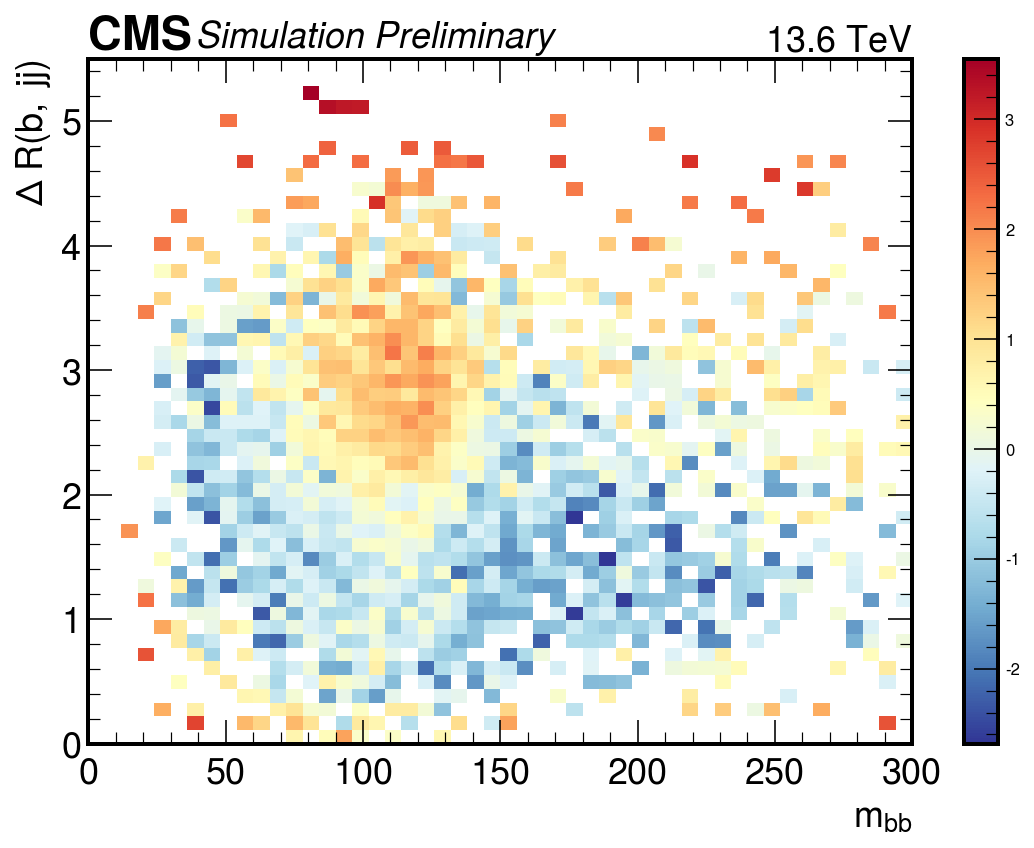

In [7]:
mapping_path = Path('/eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/JetTop_crtd_even/llr_functions.json')
analyzer = Analyzer(workspace, config, mapping_path, output_dir=Path('.'))
analyzer.plot_sig_bkg(refs1D[7])
analyzer.plot_ratio(refs1D[7])
analyzer.plot_sig_bkg(refs2D[5])
analyzer.plot_ratio(refs2D[5])
analyzer.plot_ratio(Reference('SL_4j_resolved___bjet_bijet_dR_vs_bjets_mbb'))